In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("data/cats_dataset.csv")
print("Dimensions :", df.shape)
df.head()

Dimensions : (1000, 5)


,Breed,Age (Years),Weight (kg),Color,Gender
0,Russian Blue,19,7,Tortoiseshell,Female
1,Norwegian Forest,19,9,Tortoiseshell,Female
2,Chartreux,3,3,Brown,Female
3,Persian,13,6,Sable,Female
4,Ragdoll,10,8,Tabby,Male


In [3]:
# Renommer les colonnes pour simplifier la manipulation
df = df.rename(columns={"Age (Years)": "age", "Weight (kg)": "weight"})

# Vérifier les valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

# Statistiques descriptives des variables numériques
df[["age", "weight"]].describe()

Valeurs manquantes par colonne :
Breed     0
age       0
weight    0
Color     0
Gender    0
dtype: int64


,age,weight
count,1000.000000,1000.00000
mean,10.210000,5.55000
std,5.535751,2.22676
min,1.000000,2.00000
25%,5.000000,4.00000
50%,10.000000,6.00000
75%,15.000000,7.00000
max,19.000000,9.00000


In [4]:
# On clusterise sur les deux variables numériques : âge et poids
features = df[["age", "weight"]].copy()

# Normalisation : indispensable pour k-means.
# Sans elle, une variable à grande échelle domine le calcul des distances.
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Avant normalisation (moyennes) :", features.mean().values)
print("Après normalisation (moyennes) :", features_scaled.mean(axis=0).round(3))
print("Après normalisation (écarts-types) :", features_scaled.std(axis=0).round(3))

Avant normalisation (moyennes) : [10.21  5.55]
Après normalisation (moyennes) : [-0.  0.]
Après normalisation (écarts-types) : [1. 1.]


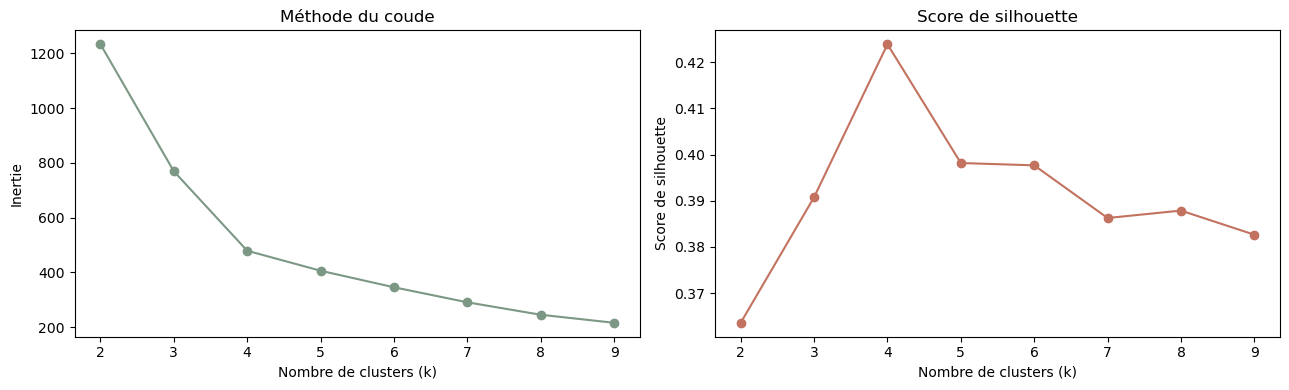

In [5]:
inerties = []
silhouettes = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(features_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(features_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(k_range), inerties, "o-", color="#7c9885")
ax1.set_xlabel("Nombre de clusters (k)")
ax1.set_ylabel("Inertie")
ax1.set_title("Méthode du coude")

ax2.plot(list(k_range), silhouettes, "o-", color="#c2725f")
ax2.set_xlabel("Nombre de clusters (k)")
ax2.set_ylabel("Score de silhouette")
ax2.set_title("Score de silhouette")

plt.tight_layout()
plt.show()

In [6]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(features_scaled)

# Combien de chats dans chaque cluster ?
print("Répartition des chats par cluster :")
print(df["cluster"].value_counts().sort_index())

Répartition des chats par cluster :
cluster
0    249
1    256
2    247
3    248
Name: count, dtype: int64


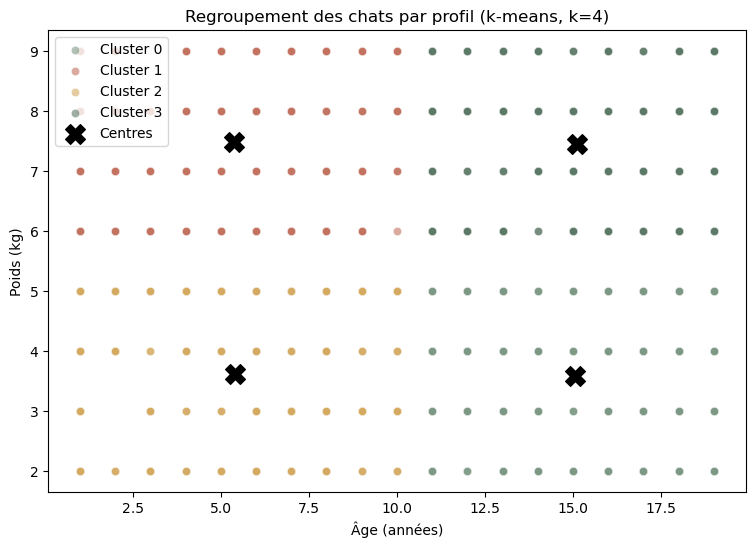

In [7]:
plt.figure(figsize=(9, 6))

colors = ["#7c9885", "#c2725f", "#d4a960", "#5c7866"]
for c in range(K):
    subset = df[df["cluster"] == c]
    plt.scatter(subset["age"], subset["weight"],
                c=colors[c], label=f"Cluster {c}", alpha=0.6, edgecolors="white", linewidth=0.5)

# Afficher les centres des clusters (ramenés à l'échelle d'origine)
centres = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centres[:, 0], centres[:, 1],
            c="black", marker="X", s=200, label="Centres", zorder=5)

plt.xlabel("Âge (années)")
plt.ylabel("Poids (kg)")
plt.title("Regroupement des chats par profil (k-means, k=4)")
plt.legend()
plt.show()

In [8]:
# Profil moyen de chaque cluster (en valeurs réelles)
profils = df.groupby("cluster")[["age", "weight"]].mean().round(1)
profils["effectif"] = df["cluster"].value_counts().sort_index()
print("Profil moyen par cluster :")
profils

Profil moyen par cluster :


,age,weight,effectif
cluster,,,
0,15.0,3.6,249
1,5.4,7.5,256
2,5.4,3.6,247
3,15.1,7.5,248
